# 磁通量绳(fluxrope)数值实验

> 2026年云南天文台暑期学校“理论与计算太阳物理”方向 (2026/7/28)

## 纲要

1. 二维/2.5D 理想 MHD 的初边值问题；
2. 无量纲化过程；
3. 有限半径轴向电流 $J_z(r)$ 获得磁通量绳的磁场分布 $B_\phi(r)$，镜像电流和背景偶极场；
4. 模型的几何参数；
5. 用压力梯度平衡电流绳内部的洛伦兹力；
6. 理解 Athena 如何用 $A_z$ 生成磁场并开展随时间的演化模拟；
7. 参数修改与思考；
8. 重力分层大气；
9. 采用MPI-AMRVAC 开展数值模拟。

## 模型范围

- 坐标：$(x,y,z)$，物理区域为 $y\ge 0$，光球位于 $y=0$；
- 2.5D：$\partial/\partial z=0$，但变量可保留三个分量；

**参考文献：** 
- T. G. Forbes (1990), *Numerical Simulation of a Catastrophe Model for Coronal Mass Ejections*, JGR 95(A8), 11919–11931
- Wang Hongjuan and Shen Chengcai and Lin Jun (2009), *Numerical Experiments of Wave-like Phenomena Caused by the Disruption of an Unstable Magnetic Configuration*, The Astrophysical Journal, 700, 1716-1731
- Mei Zhingxing, Shen Chengcai, Wu Ning, N. A. Murpy and I. I. Roussev (2012), *Numerical experiments on magnetic reconnection in solar flare and coronal mass ejection current sheets*, MNRAS, 425, 2824-2839

In [1]:
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": False,
    "font.size": 11,
})


@dataclass(frozen=True)
class ModelParameters:
    """Dimensionless parameters following the Forbes (1990) setup."""

    gamma: float = 5.0 / 3.0
    pgas_c: float = 1.0 / (5.0 / 3.0)
    rho_c: float = 1.0
    xc: float = 0.0
    h: float = 0.125
    hb: float = 0.0625
    ri: float = 0.050
    delta: float = 0.025
    J0: float = 600.0
    rmom: float = 1.0


P = ModelParameters()
r1 = P.ri - 0.5 * P.delta
r2 = P.ri + 0.5 * P.delta


# All reusable functions used in this notebook
def current_density(r):
    """Return the dimensionless axial current density J_z(r)."""
    r = np.asarray(r, dtype=float)
    result = np.zeros_like(r)
    core = r <= r1
    shell = (r > r1) & (r <= r2)
    result[core] = P.J0
    result[shell] = 0.5 * P.J0 * (
        1.0 + np.cos(np.pi * (r[shell] - r1) / P.delta)
    )
    return result


def bphi(r):
    """Return the dimensionless azimuthal field B_phi(r)."""
    r = np.asarray(r, dtype=float)
    result = np.zeros_like(r)
    delta2 = P.delta**2
    pi2 = np.pi**2

    core = r <= r1
    shell = (r > r1) & (r <= r2)
    exterior = r > r2

    result[core] = -0.5 * P.J0 * r[core]
    shell_radius = r[shell]
    if shell_radius.size:
        phase = np.pi * (shell_radius - r1) / P.delta
        profile = (
            0.5 * r1**2 - delta2 / pi2 + 0.5 * shell_radius**2
            + P.delta * shell_radius / np.pi * np.sin(phase)
            + delta2 / pi2 * np.cos(phase)
        )
        result[shell] = -0.5 * P.J0 * profile / shell_radius

    exterior_radius = r[exterior]
    if exterior_radius.size:
        enclosed = P.ri**2 + 0.25 * delta2 - 2.0 * delta2 / pi2
        result[exterior] = -0.5 * P.J0 * enclosed / exterior_radius
    return result


def safe_bphi_over_r(r):
    """Return B_phi/r with its analytic finite limit at r=0."""
    r = np.asarray(r, dtype=float)
    result = np.empty_like(r)
    regular = r > 1.0e-14
    result[regular] = bphi(r[regular]) / r[regular]
    result[~regular] = -0.5 * P.J0
    return result


def magnetic_components(x, y):
    """Return rope, image, dipole, and total fields as (Bx, By) tuples."""
    shifted_x = x - P.xc
    rope_y = y - P.h
    image_y = y + P.h
    dipole_y = y + P.hb
    rope_radius = np.hypot(shifted_x, rope_y)
    image_radius = np.hypot(shifted_x, image_y)
    dipole_radius2 = shifted_x**2 + dipole_y**2

    rope_factor = safe_bphi_over_r(rope_radius)
    image_factor = safe_bphi_over_r(image_radius)
    coefficient = float(bphi(np.array([r2]))[0]) * P.rmom * P.hb * r2

    rope = (rope_factor * rope_y, -rope_factor * shifted_x)
    image = (-image_factor * image_y, image_factor * shifted_x)
    dipole = (
        -coefficient * (shifted_x**2 - dipole_y**2) / dipole_radius2**2,
        -2.0 * coefficient * shifted_x * dipole_y / dipole_radius2**2,
    )
    total = (
        rope[0] + image[0] + dipole[0],
        rope[1] + image[1] + dipole[1],
    )
    return rope, image, dipole, total


def cumulative_trapezoid_from_right(values, coordinates):
    """Integrate from each coordinate to the right endpoint."""
    segment = 0.5 * (values[:-1] + values[1:]) * np.diff(coordinates)
    result = np.zeros_like(values)
    result[:-1] = np.cumsum(segment[::-1])[::-1]
    return result


def equilibrium_profiles(radius):
    """Return pressure and density profiles for radial rope balance."""
    radius = np.asarray(radius, dtype=float)
    integrand = bphi(radius) * current_density(radius)
    pressure = P.pgas_c - cumulative_trapezoid_from_right(integrand, radius)
    density = P.rho_c * (pressure / P.pgas_c)**(1.0 / P.gamma)
    return pressure, density

## 1. MHD 方程组与初边值问题

这里是有量纲的理想 MHD 方程。为避免与下一节 Forbes 的无量纲变量混淆，本节暂时仍用 $\mu_0$ 显式表示 SI 制磁导率；下一节再给出 Forbes（1990）的归一化。

$$
\frac{\partial \rho}{\partial t}+\nabla\cdot(\rho\mathbf v)=0,
$$

$$
\frac{\partial(\rho\mathbf v)}{\partial t}
+\nabla\cdot\left[\rho\mathbf v\mathbf v+
\left(p+\frac{B^2}{2\mu_0}\right)\mathbf I-
\frac{\mathbf B\mathbf B}{\mu_0}\right]=0,
$$

$$
\frac{\partial E}{\partial t}+
\nabla\cdot\left[\left(E+p+\frac{B^2}{2\mu_0}\right)\mathbf v
-\frac{(\mathbf v\cdot\mathbf B)\mathbf B}{\mu_0}\right]=0,
$$

$$
\frac{\partial\mathbf B}{\partial t}-\nabla\times(\mathbf v\times\mathbf B)=0,
\qquad \nabla\cdot\mathbf B=0,
$$

其中

$$
E=\frac{p}{\gamma-1}+\frac12\rho v^2+\frac{B^2}{2\mu_0},
\qquad p=(\gamma-1)\left(E-\frac12\rho v^2-\frac{B^2}{2\mu_0}\right).
$$

若加入电阻率，感应方程变为

$$
\frac{\partial\mathbf B}{\partial t}
=\nabla\times(\mathbf v\times\mathbf B)-\nabla\times(\eta\mathbf J),
\qquad \mathbf J=\frac{1}{\mu_0}\nabla\times\mathbf B.
$$

### 什么是初边值问题？

给定：

- **初始条件**：$\rho(x,y,0),p(x,y,0),\mathbf v(x,y,0),\mathbf B(x,y,0)$；
- **边界条件**：每一条边界上允许哪些量进入、离开或被固定。

求解上述磁流体力学方程组，得到

$$
\rho(x,y,t),\quad p(x,y,t),\quad\mathbf v(x,y,t),\quad\mathbf B(x,y,t),
$$

即磁场与等离子体空间分布随时间的演化。

## 2. Forbes（1990）的无量纲化

这一节我们以 Forbes（1990）第 3.1 节为例，介绍MHD模拟过程中的无量纲化过程。

论文用带撇号的量表示有量纲物理量，用不带撇号的量表示无量纲量。设环境日冕的密度、温度、气压和声速分别为 $\rho_c'$、$T_c'$、$p_c'$ 和 $c_s'$，并定义

$$
c_s'^2=\gamma R'T_c',
$$

其中 $R'$ 是气体常数，$\gamma$ 是比热比。密度、气压、速度和磁场的无量纲化为

$$
\rho=\frac{\rho'}{\rho_c'},
\qquad
p=\frac{p'}{\gamma R'\rho_c'T_c'}
=\frac{p'}{\rho_c'c_s'^2},
$$

$$
\mathbf v=\frac{\mathbf v'}{c_s'},
\qquad
\mathbf B=\frac{\mathbf B'}{c_s'\sqrt{\mu'\rho_c'}}.
$$

磁场特征量为：

$$
B_c'=c_s'\sqrt{\mu'\rho_c'}
$$

这样，当 $|\mathbf B|=1$ 时

$$
v_A'=\frac{B_c'}{\sqrt{\mu'\rho_c'}}=c_s'.
$$

无量纲温度为

$$
T=\frac{T'}{\gamma T_c'}.
$$

空间和时间坐标定义为

$$
x=\frac{x'}{w'},
\qquad
y=\frac{y'}{w'},
\qquad
t=\frac{t'c_s'}{w'},
$$

其中 $w'$ 取为从对称轴到侧边界的计算域宽度。因此论文计算区域为

$$
0<x<1,\qquad 0<y<2,
$$

相应的时间是

$$
t_c'=\frac{w'}{c_s'}.
$$

电流密度的无量纲化为

$$
\mathbf j=\frac{\mu'w'\mathbf j'}{B_c'}
=\frac{\mu'w'\mathbf j'}{c_s'\sqrt{\mu'\rho_c'}}.
$$

若取
$$
\rho_0=1,
\qquad
p_0=\frac{1}{\gamma},
\qquad
\gamma=\frac53.
$$

则无量纲绝热声速为

$$
c_s=\sqrt{\frac{\gamma p_0}{\rho_0}}=1,
$$

注意：Forbes 没有在这里指定唯一的 SI 制 $w'$、$\rho_c'$ 或 $T_c'$；若不额外选择环境日冕参数，就不应把无量纲长度和时间强行换算成 km 和 s。

### 示例：无量纲结果映射到典型太阳活动

下面取一个典型日冕参数：

$$
T_c'=10^6\ {\rm K},\qquad
n_e'=10^9\ {\rm cm^{-3}},\qquad
w'=10^5\ {\rm km}.
$$

这里 $w'$ 是从对称轴 $x=0$ 到侧边界 $x=1$ 的物理宽度；若绘制完整区域 $-1<x<1$，其总物理宽度是 $2w'$。

为了由电子数密度估算质量密度，还需要给出日冕元素组成。以下采用完全电离、含少量氦的典型近似：

$$
\rho_c'\simeq1.2m_pn_e',
\qquad
\bar\mu\simeq0.6,
$$

其中 $\bar\mu m_p$ 是每个自由粒子的平均质量。环境绝热声速为

$$
c_s'=\sqrt{\frac{\gamma k_BT_c'}{\bar\mu m_p}},
$$

而 Forbes 的时间、磁场和压力单位随之确定：

$$
t_c'=\frac{w'}{c_s'},\qquad
B_c'=c_s'\sqrt{\mu_0\rho_c'},\qquad
p_c'=\rho_c'c_s'^2.
$$

任意无量纲结果可恢复为

$$
x'=xw',\qquad
t'=tt_c',\qquad
\mathbf v'=\mathbf v c_s',
$$

$$
\rho'=\rho\rho_c',\qquad
p'=pp_c',\qquad
\mathbf B'=\mathbf B B_c'.
$$

In [2]:
# An example
k_B = 1.380649e-23          # J K^-1
m_p_si = 1.67262192369e-27  # kg
mu0_si = 4.0e-7 * np.pi     # N A^-2

T_corona = 1.0e6            # K
ne_corona = 1.0e9 * 1.0e6   # 10^9 cm^-3 -> m^-3
w_corona = 1.0e5 * 1.0e3    # 10^5 km -> m
mean_molecular_weight = 0.6
mass_per_electron = 1.2     # rho approximately 1.2 m_p n_e

gamma_forbes = 5.0 / 3.0

rho_corona = mass_per_electron * m_p_si * ne_corona
cs_corona = np.sqrt(gamma_forbes * k_B * T_corona /
                    (mean_molecular_weight * m_p_si))
time_unit = w_corona / cs_corona
magnetic_unit = cs_corona * np.sqrt(mu0_si * rho_corona)
pressure_unit = rho_corona * cs_corona**2

print("Coronal environment")
print(f"  T_c'   = {T_corona:.2e} K")
print(f"  n_e'   = {ne_corona / 1e6:.2e} cm^-3")
print(f"  w'     = {w_corona / 1e3:.2e} km")
print(f"  rho_c' = {rho_corona:.3e} kg m^-3")
print("\nDerived characteristic parameters")
print(f"  c_s'   = {cs_corona / 1e3:.1f} km s^-1")
print(f"  t_c'   = {time_unit:.1f} s = {time_unit / 60:.2f} min")
print(f"  B_c'   = {magnetic_unit * 1e4:.2f} G")
print(f"  p_c'   = {pressure_unit:.3e} Pa = {pressure_unit * 10:.3f} dyn cm^-2")

Coronal environment
  T_c'   = 1.00e+06 K
  n_e'   = 1.00e+09 cm^-3
  w'     = 1.00e+05 km
  rho_c' = 2.007e-12 kg m^-3

Derived characteristic parameters
  c_s'   = 151.4 km s^-1
  t_c'   = 660.4 s = 11.01 min
  B_c'   = 2.40 G
  p_c'   = 4.602e-02 Pa = 0.460 dyn cm^-2


## 3. 三部分磁场

整个初始磁场由3部分组成：

$$
\mathbf B
=\mathbf B_{\rm rope}
+\mathbf B_{\rm image}
+\mathbf B_{\rm dipole}.
$$

1. **真实电流绳产生的磁场 $\mathbf B_{\rm rope}$**  
   电流绳位于日冕计算区域内，电流沿 $z$ 方向。它周围形成环绕绳轴的环向磁场，是我们要研究的主体结构。

2. **镜像电流绳产生的磁场 $\mathbf B_{\rm image}$**  
   在光球下方放置一个方向相反的镜像电流。它是计算域外的数学源，不是第二条真实的日冕磁通量绳。它的作用是让电流绳系统在光球 $y=0$ 满足理想电导体边界的要求。

3. **埋藏偶极子产生的背景场 $\mathbf B_{\rm dipole}$**  
   偶极子位于光球以下，代表约束磁通量绳的外部日冕磁场（或者浮现的磁场）。它提供向下的磁约束，与镜像电流带来的向上作用竞争。

因此，这个灾变模型的核心不是单独一条电流绳，而是三部分磁场之间的力学竞争。
改变磁通量绳的电流强度（也即环向的磁场强度）、磁通量绳高度或偶极场强度，都可能打破原有平衡，从而使磁通量绳便从缓慢演化转入快速抬升。下图显示了三部分磁场位型。

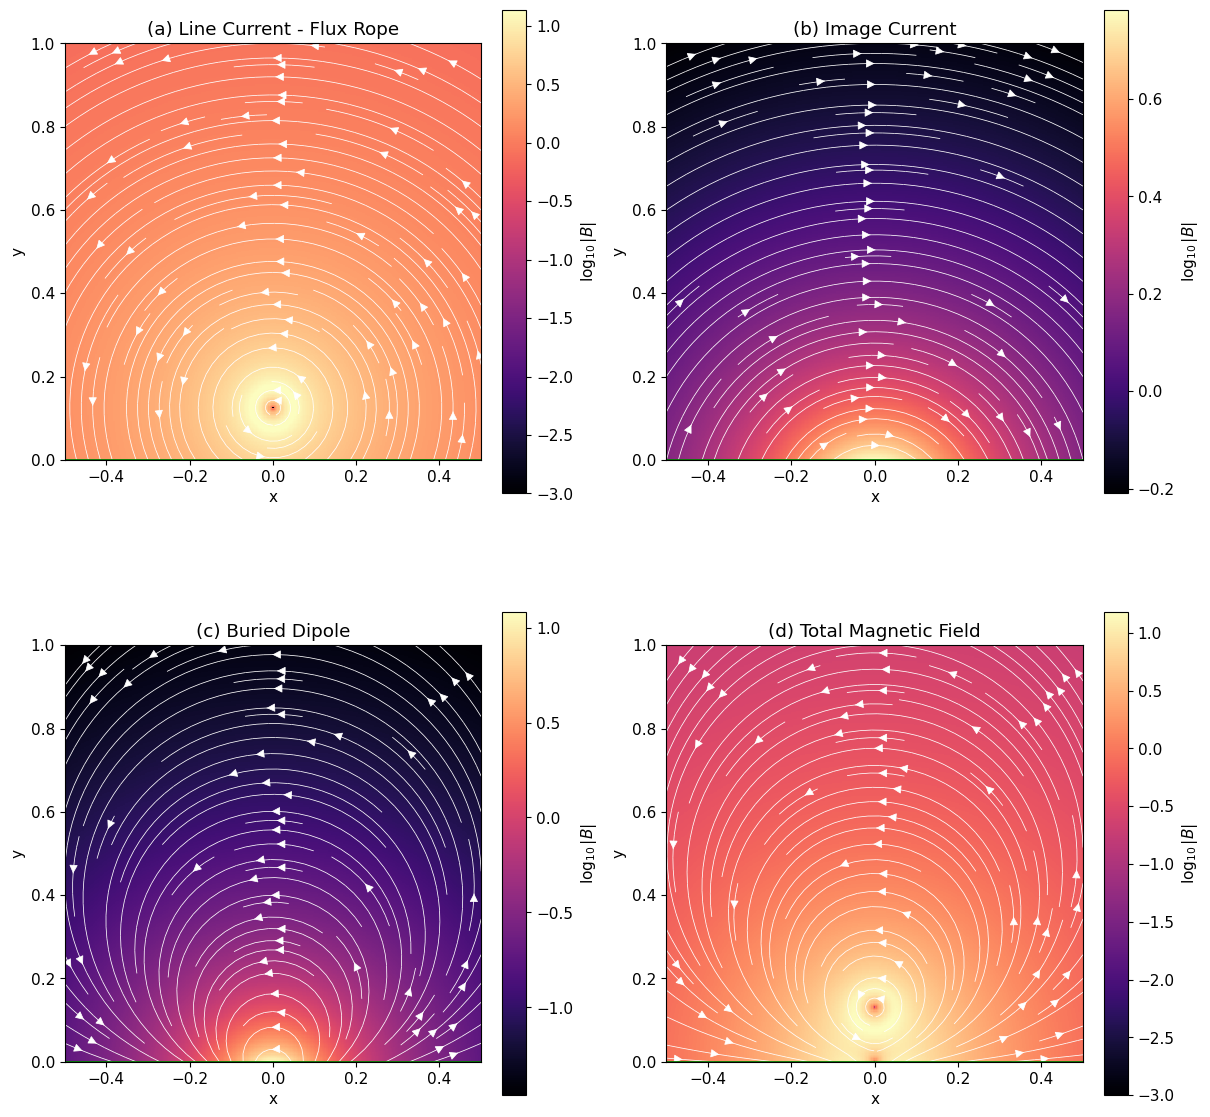

In [3]:
# show magnetic field components
x = np.linspace(-0.5, 0.5, 321)
y = np.linspace(0.0, 1.0, 321)
XG, YG = np.meshgrid(x, y)
field_parts = magnetic_components(XG, YG)
titles = [
    "(a) Line Current - Flux Rope",
    "(b) Image Current",
    "(c) Buried Dipole",
    "(d) Total Magnetic Field",
]
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
for axis, (bx_part, by_part), title in zip(axes.flat, field_parts, titles):
    magnitude = np.hypot(bx_part, by_part)
    color = np.log10(np.maximum(magnitude, 1.0e-3))
    image = axis.pcolormesh(x, y, color, shading="auto", cmap="magma")
    axis.streamplot(x, y, bx_part, by_part, color="white", density=1.2,
                    linewidth=0.55, arrowsize=1.3)
    axis.axhline(0.0, color="green", linewidth=2)

    axis.set(xlim=(-0.5, 0.5), ylim=(0.0, 1.0), aspect="equal",
             xlabel="x", ylabel="y", title=title)
    fig.colorbar(image, ax=axis, shrink=0.82, label=r"$\log_{10}|B|$")
plt.show()

## 4. 模型的几何参数

| 物理量 | Forbes1990 符号 | Notebook 参数 | 数值 |
|---|---:|---:|---:|
| 电流绳高度 | $h_0$ | `P.h` | $0.125$ |
| 埋藏偶极深度 | $d$ | `P.hb` | $0.0625$（本示例） |
| 电流绳半径 | $r$ | `P.ri` | $0.050$ |
| 过渡层宽度 | $\Delta$ | `P.delta` | $0.025$ |
| 中心电流密度 | $J_0$ | `P.J0` | $600$ |
| 偶极强度因子 | $M$ | `P.rmom` | $1.0$（本示例） |

以电流绳轴为 $x=0$，定义

$$
r_s=\sqrt{x^2+(y-h_0)^2},\quad
r_m=\sqrt{x^2+(y+h_0)^2},\quad
r_b=\sqrt{x^2+(y+d)^2}.
$$

三个距离分别指向真实电流绳、光球下的镜像电流绳和埋藏偶极子。

### 磁绳内部的电流分布

令

$$
r_1=r-\frac{\Delta}{2},\qquad
r_2=r+\frac{\Delta}{2}.
$$

轴向电流密度为

$$
J_z(R)=
\begin{cases}
J_0, & R\le r_1,\\
\dfrac{J_0}{2}\left[1+\cos\dfrac{\pi(R-r_1)}{\Delta}\right], & r_1<R\le r_2,\\
0, & R>r_2.
\end{cases}
$$

余弦过渡层避免在电流绳边缘引入电流密度跃变。

## 5. 等离子体初态：压力、密度与速度

用等离子体的气体压力梯度力平衡磁绳内部的环向磁场产生径向洛伦兹力：

$$
\frac{dp}{dr}=J_zB_\phi.
$$

因此，一旦给定磁绳的磁场大小，即可得到磁绳内的气体压力分布：

$$
p(r)=p_c-\int_r^\infty B_\phi(r')J_z(r')\,dr'
=p_c-\int_r^{r_2}B_\phi(r')J_z(r')\,dr',
$$

第二个等号成立是因为 $r>r_2$ 时 $J_z=0$。`func_uphi()` 使用自适应 Simpson 法计算该积分。

在这里简单的例子里，我们加速没有重力并采用绝热关系来定义等离子体密度：

$$
\rho(r)=\rho_c\left(\frac{p(r)}{p_c}\right)^{1/\gamma},
\qquad \mathbf v(x,y,0)=0.
$$

这保证了磁绳内部的径向方向的压力平衡，但过大的磁绳半径、数值误差也使我们的位型并不是完美平衡的。

## 6. 为什么用磁矢势（$A_z$）初始化磁场？

在二维情况下磁矢势（$A_z$）和磁场分量的关系如下：

$$
B_x=\frac{\partial A_z}{\partial y},\qquad
B_y=-\frac{\partial A_z}{\partial x}.
$$

于是可知

$$
\nabla\cdot\mathbf B
=\frac{\partial^2A_z}{\partial x\partial y}
-\frac{\partial^2A_z}{\partial y\partial x}=0.
$$

Athena 是有限体积法，$B_x$ 和 $B_y$ 分别存放在垂直于 $x$、$y$ 的网格面。当前 `init_azini_from_b()` 先在计算网格的顶点获得 $A_z$，然后使用

$$
B_{x,i,j}=\frac{A_{z,i,j+1}-A_{z,i,j}}{\Delta y},\qquad
B_{y,i,j}=-\frac{A_{z,i+1,j}-A_{z,i,j}}{\Delta x}.
$$

对每个网格单元(cell)重新计算磁场，相邻差分逐项相消，因此离散散度可达到机器精度。这比把解析 $B_x,B_y$ 分别采样到面中心更稳健。

Bx_face shape: (140, 181)
By_face shape: (141, 180)
cell divB shape: (140, 180)
max normalized |div B| = 2.082e-16


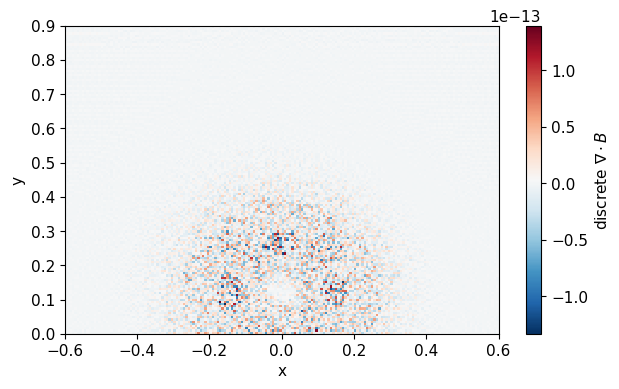

In [4]:
# A compact discrete-curl demonstration on a corner grid
nx, ny = 180, 140
x_edges = np.linspace(-0.6, 0.6, nx + 1)
y_edges = np.linspace(0.0, 0.9, ny + 1)
dx = x_edges[1] - x_edges[0]
dy = y_edges[1] - y_edges[0]
XC, YC = np.meshgrid(x_edges, y_edges)

# Any smooth Az works for this algebraic test.
Az = np.exp(-((XC - P.xc)**2 + (YC - P.h)**2) / 0.04) + 0.15 * XC * YC

# Face fields: Bx has shape (ny, nx+1), By has shape (ny+1, nx).
Bx_face = (Az[1:, :] - Az[:-1, :]) / dy
By_face = -(Az[:, 1:] - Az[:, :-1]) / dx

# Cell divergence from differences of normal face fields.
divB = ((Bx_face[:, 1:] - Bx_face[:, :-1]) / dx
        + (By_face[1:, :] - By_face[:-1, :]) / dy)
field_scale = max(np.max(np.abs(Bx_face)), np.max(np.abs(By_face)))
normalized_divergence = np.max(np.abs(divB)) * min(dx, dy) / field_scale

print(f"Bx_face shape: {Bx_face.shape}")
print(f"By_face shape: {By_face.shape}")
print(f"cell divB shape: {divB.shape}")
print(f"max normalized |div B| = {normalized_divergence:.3e}")

fig, ax = plt.subplots(figsize=(7, 4))
view = ax.pcolormesh(0.5 * (x_edges[:-1] + x_edges[1:]),
                     0.5 * (y_edges[:-1] + y_edges[1:]),
                     divB, shading="auto", cmap="RdBu_r")
fig.colorbar(view, ax=ax, label=r"discrete $\nabla\cdot B$")
ax.set(xlabel="x", ylabel="y")
plt.show()

## 初始条件与边界条件

| 位置/变量 | 实现方式 | 物理含义 |
|---|---|---|
| 初始速度 | $\mathbf v=0$ | 初始从静止开始 |
| 初始磁场 | 电流绳 + 镜像 + 偶极，再经 $A_z$ 取离散旋度 | 保持 $\nabla\cdot\mathbf B=0$ |
| 初始压力 | $p=p_c-\int_r^{r_2}B_\phi J_z\,dr$ | 磁绳内部径向平衡 |
| 初始密度 | $\rho=\rho_c(p/p_c)^{1/\gamma}$ | 磁绳内绝热 |
| 底边速度 | $v_x=v_y=v_z=0$ | line-tied |
| 底边法向场 | $B_y(x,0,t)=B_y(x,0,0)$ | line-tied |
| 底边切向场 | $\partial B_x/\partial y=\partial B_y/\partial x$ | line-tied |
| 底边热力学 | $\partial p/\partial y=0$，再由绝热关系给 $\rho$ | 静压平衡 |
| 顶边 | 开放/外推 | 允许流入流出 |
| 左右边 | 当前全区域输入使用 Athena 边界设置 | 允许流入流出 |

### 执行流程

```text
configure --with-problem=fluxrope
      |  将 src/prob/fluxrope.c 选为 src/problem.c
      v
compile
      |  编译程序为可执行程序athena
      v
athinput.fluxrope
      |  定义必要的模型参数
      v
problem(): 读取参数
      |
      +--> Jz(r) --> Bphi(r)
      +--> 真实绳 + 镜像 + 偶极的解析 Bx, By
      +--> Az --> B
      +--> p(r), rho(r), v=0 --> 守恒变量 U
      v
CTU + HLLD + constrained transport
      |
      +--> 随时间的演化，每步更新边界条件
      v
HST / VTK 输出 --> plot_var_fluxrope_tutorial.ipynb
```

## 7. 参数修改与思考

1. **改变偶极强度 `rmom`**：比较背景磁场约束带来的变化。
2. **改变 `h` 或 `rja`**：观察平衡情况和失稳后的速度变化。
3. **收敛性测试**：使用 $200^2,400^2,800^2$ 不同的网格比较磁绳高度 $h(t)$的演化。
4. **理想MHD与resistive MHD**：(参见另一个数值实验)。

### 小结

本模型的构造顺序是：

$$
J_z(r)\longrightarrow B_\phi(r)
\longrightarrow \mathbf B_{\rm rope}+\mathbf B_{\rm image}+\mathbf B_{\rm dipole}
\longrightarrow A_z\longrightarrow \nabla_h\cdot\mathbf B=0,
$$

同时

$$
B_\phi J_z\longrightarrow p(r)
\longrightarrow \rho(r),\qquad \mathbf v(t=0)=0.
$$

## 8. 重力分层大气

太阳表面重力加速度$g_\odot=\frac{G M_\odot}{R_\odot^2}=274m s^{-2}$，在高度r处的重力加速度为$g=g_\odot (\frac{R_\odot}{r})^2$，处于静态平衡的重力分层大气满足：

$$
\frac{d p}{d r} + \rho g =0
\longrightarrow
\frac{d p}{d r} + \frac{p}{2 n_e K_B T_e} (\mu n_e m_p) g_\odot \left(\frac{R_\odot}{r}\right)^2  =0
\longrightarrow
\frac{d p}{p}=-dr \frac{\mu m_p g_\odot}{2 K_B T_e} \left(\frac{r}{R_\odot}\right)^{-2}
$$
所以：
$$
p=p_0 exp\left[-\frac{1}{\lambda} \frac{r-r_0}{r/ R_\odot}\right],\ \ \lambda=\frac{\mu m_p g_\odot}{2 K_B T_e}\approx 4.7\times 10^9 \left(\frac{T_e}{1 MK}\right)  \text{(cm)}
$$


## 9. 采用MPI-AMRVAC开展数值模拟
参考链接：amrvac.org

初始条件和边界条件：mod_usr.t

算法与网格相关参数设置：amrvac.par

作业提交命令：sbatch runscript

数据上传下载：scp命令

数据可视化：Paraview